In [51]:
# Section 0: Setup
import urllib.request, zipfile, io, os, json, textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)
# Force pandas to show regular floats instead of scientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)


### China area codes across FAOSTAT datasets

| Code | Label | QCL (production) | TCL (trade) | TM (trade) | What it is |
|------|-------|:----------------:|:-----------:|:----------:|------------|
| **41** | China, mainland | ✅ | ✅ | ✅ | Mainland only — **the entity used** |
| 351 | China | ✅ | ✅ | ✅ | Aggregate: mainland + Taiwan + Hong Kong + Macao |
| 357 | China (mainland + Taiwan) | — | ✅ | ✅ | Aggregate: mainland + Taiwan (trade domains only) |
| 214 | China, Taiwan Province of | ✅ | ✅ | ✅ | Taiwan as a standalone territory |
| 96 | China, Hong Kong SAR | ✅ | ✅ | ✅ | Hong Kong as a standalone territory |
| 128 | China, Macao SAR | ✅ | ✅ | ✅ | Macao as a standalone territory |

**Why only code 41 (China, mainland):**

- **No double-counting** — 351 and 357 already contain the mainland, so keeping them alongside 41 counts mainland output/trade twice (the inflation bug seen in the production ranking).
- **Cross-dataset consistency** — production (QCL) is divided by trade (TCL/TM), so "China" must be the *same entity* in every file. Code 41 is the only China code present cleanly in all three; the aggregates differ by domain (351 everywhere, 357 trade-only).
- **Trade realism** — 351 bundles in Hong Kong, a major entrepôt whose re-export flows would inflate "China's" trade with goods that never originated on the mainland.
- **Stated scope** — 41 is mainland-only (excludes Taiwan 214, Hong Kong 96, Macao 128). Methodology note: **"China" = mainland, FAO code 41.**

In [54]:
# Section 0: Data principles, encoded as config so every downstream calc references the same
# assumptions instead of re-deciding them inline.
CONFIG = {
    # --- Scope for production ---
    'crop_item_code': 113,        # FAOSTAT Item Code for Rice (verified in Section 1)
    'crop_name': 'Rice',

   # --- Scope for trade ----
   # Rice with item code 113 (in QCL data) is not traded straight forward as 113, 
   # it inturn is traded in multiple forms (Rice;milled and Rice; milled (husked) as layer 1 and 2) 
   # and there is a conversion factor associated with this
   # Reference PDF: https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content
   # Can be navigated from: https://openknowledge.fao.org/home
   # Keyed by the CPC code as it appears in Trade_CropsLivestock_E_ItemCodes.
   # The 
    'trade_crop_item_code_rm': 31,
    'trade_crop_name_rm' : 'Rice; milled', # Turns into broken rice (code 32)
    'rm_paddy_factor': 0.67,
    'trade_crop_item_code_rmh': 28,
    'trade_crop_name_rmh' : 'Husked rice', # turns into milled husked rice (code 29)
    'rmh_paddy_factor': 0.77,


    # # --- Years ---
    # # Single-year production/trade figures are noisy (one bad harvest, one reporting gap).
    # # Use a trailing N-year average, anchored to the latest year with broad country coverage,
    # # for anything used to rank/classify countries. Time-series charts still use the full history.
    # 'trailing_avg_years': 3,

    # --- Drop Area codes----
    # Excluding regional/continental aggregates (<5000)
    # Table above has an explaination about how China's area codes are represented in the FAOSTAT datset
    'aggregate_code_cutoff': 5000,
    'exclude_area_codes': [351, 357,214,96,128],

    # --- Scope of "major producer" / "major supplier" ---
    'top_n_producers': 15,        
    'top_n_exporters': 15, 
    'top_n_importers_display': 15,

    # --- Imputation / exclusion rules ---
    # - Drop FAOSTAT regional/continental aggregates (Area/Reporter/Partner Code >= 5000) everywhere
}

# Caveat repeated throughout the brief: FAOSTAT does not separate brewing barley from feed/food
# barley. Every number in this notebook is total barley; beer is the storytelling frame, not the
# analytical scope.
print(json.dumps({k: v for k, v in CONFIG.items() if k != 'water_stress_bins'}, indent=2, default=str))


{
  "crop_item_code": 113,
  "crop_name": "Rice",
  "trade_crop_item_code_rm": 31,
  "trade_crop_name_rm": "Rice; milled",
  "rm_paddy_factor": 0.67,
  "trade_crop_item_code_rmh": 28,
  "trade_crop_name_rmh": "Husked rice",
  "rmh_paddy_factor": 0.77,
  "aggregate_code_cutoff": 5000,
  "exclude_area_codes": [
    351,
    357,
    214,
    96,
    128
  ],
  "top_n_producers": 15,
  "top_n_exporters": 15,
  "top_n_importers_display": 15
}


Section 1a: Rice production — QCL bulk download

In [55]:
# Section 1a: QCL bulk download (Production: Crops and livestock products)
BULK_URL = 'https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip'
if not os.path.exists('qcl_bulk.zip'):
    print('Downloading QCL bulk file...')
    urllib.request.urlretrieve(BULK_URL, 'qcl_bulk.zip')

with zipfile.ZipFile('qcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    print(f'Reading {csv_name}...')
    qcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)

    item_csv = [n for n in z.namelist() if 'ItemCodes' in n][0]
    item_codes = pd.read_csv(z.open(item_csv), encoding='latin-1')

    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(f'Full QCL: {len(qcl_all):,} rows')

Reading Production_Crops_Livestock_E_All_Data_(Normalized).csv...
Full QCL: 4,209,110 rows


In [56]:
rice_matches = item_codes[item_codes['Item'].str.contains('Rice', case=False, na=False)][['Item Code', 'Item']]
print(rice_matches.to_string(index=False))

exact = rice_matches[rice_matches['Item'].str.fullmatch('Rice', case=False)]
if len(exact):
    CONFIG['crop_item_code'] = int(exact.iloc[0]['Item Code'])
else:
    print("No exact 'Rice' match in the lookup — check the table above and set CONFIG['crop_item_code'] manually.")
    CONFIG['crop_item_code'] = int(rice_matches.iloc[0]['Item Code'])  # best-effort fallback

print(f"Using Item Code {CONFIG['crop_item_code']} for Rice")

Item Code Item
       27 Rice
Using Item Code 27 for Rice


In [57]:
# Section 1c: filter to Rice Production (tonnes), then drop regional/continental aggregates (< 5000)
# AND the China aggregates/territories (keeping mainland 41 only, per CONFIG).
# Area Code isin() cast to str on both sides — the dtype mismatch here was the bug fixed in the
# original notebook's Section 3; keeping the cast explicit rather than trusting pandas to infer it.
qcl_rice = qcl_all[(qcl_all['Item Code'] == CONFIG['crop_item_code']) & (qcl_all['Element'] == 'Production')].copy()
print(f"Rice, Production element: {len(qcl_rice):,} rows, unit(s): {qcl_rice['Unit'].unique()}")
# print(qcl_rice.head())

# build the valid-country set: below the aggregate cutoff AND not an excluded China code
area_code_exclude = area_codes[
    (area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))

qcl_rice = qcl_rice[qcl_rice['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + doubly counted codes (for China): {len(qcl_rice):,} rows, {qcl_rice['Area'].nunique()} countries")
# print(qcl_rice.head())

rice_by_area_year = qcl_rice.groupby(['Area', 'Area Code', 'Year'])['Value'].sum().reset_index(name='production_t')

Rice, Production element: 9,708 rows, unit(s): ['t']
After dropping aggregates + doubly counted codes (for China): 7,544 rows, 143 countries


In [58]:
world_production_over_year = rice_by_area_year.groupby('Year')['production_t'].sum().reset_index()
print(world_production_over_year)

    Year  production_t
0   1961  213069031.00
1   1962  223766003.00
2   1963  244444925.00
3   1964  260075174.00
4   1965  251074029.00
..   ...           ...
59  2020  769854053.78
60  2021  789501998.86
61  2022  777062081.24
62  2023  803284082.38
63  2024  818174842.58

[64 rows x 2 columns]


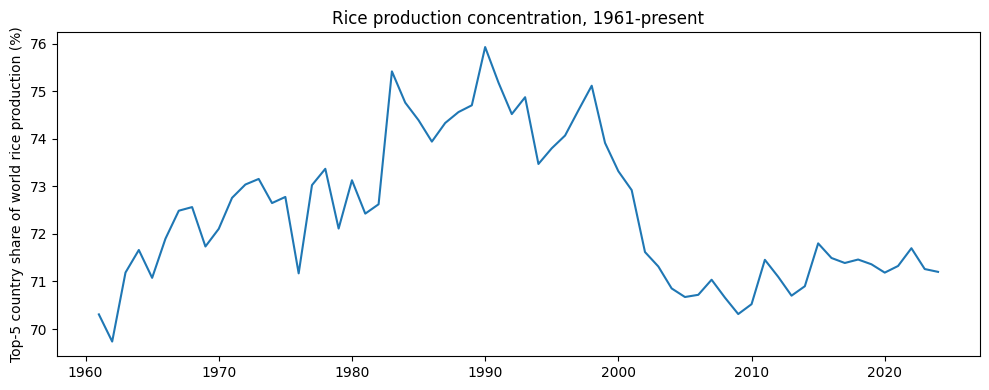

Latest top-5 share: 71.2%


In [59]:
# Full-history concentration trend (top-5 share of world production, year by year) — same metric
# as the original notebook's Section 4, recomputed here for Rice alone.
by_year_rank = rice_by_area_year.copy()
by_year_rank['rank'] = by_year_rank.groupby('Year')['production_t'].rank(ascending=False, method='min')

global_total_by_year = rice_by_area_year.groupby('Year')['production_t'].sum().reset_index(name='global_total')
top5_by_year = (by_year_rank[by_year_rank['rank'] <= 5]
                .groupby('Year')['production_t'].sum().reset_index(name='top5_total'))
concentration = top5_by_year.merge(global_total_by_year, on='Year')
concentration['top5_share_pct'] = concentration['top5_total'] / concentration['global_total'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(concentration['Year'], concentration['top5_share_pct'])
ax.set_ylabel('Top-5 country share of world rice production (%)')
ax.set_title('Rice production concentration, 1961-present')
plt.tight_layout(); plt.show()

print(f"Latest top-5 share: {concentration.sort_values('Year').iloc[-1]['top5_share_pct']:.1f}%")


#### Analysing the production (Total and Avg) for countries over a period of 2000-2024

In [60]:
#This is the total production analysis
rice_production_2000_2024 = (
    rice_by_area_year[
        (rice_by_area_year['Year'] >= 2000) &
        (rice_by_area_year['Year'] <= 2024)
    ]
    .groupby('Area')['production_t']
    .sum()
    .reset_index()
    .sort_values('production_t', ascending=False)
)

print(rice_production_2000_2024)

                                 Area  production_t
23                    China, mainland 4944787500.00
59                              India 3949568648.52
60                          Indonesia 1391403356.54
7                          Bangladesh 1209116494.14
138                          Viet Nam 1004997339.59
..                                ...           ...
99                             Poland          0.00
30                             Cyprus          0.00
111                          Slovakia          0.00
112                          Slovenia          0.00
107  Saint Vincent and the Grenadines          0.00

[141 rows x 2 columns]


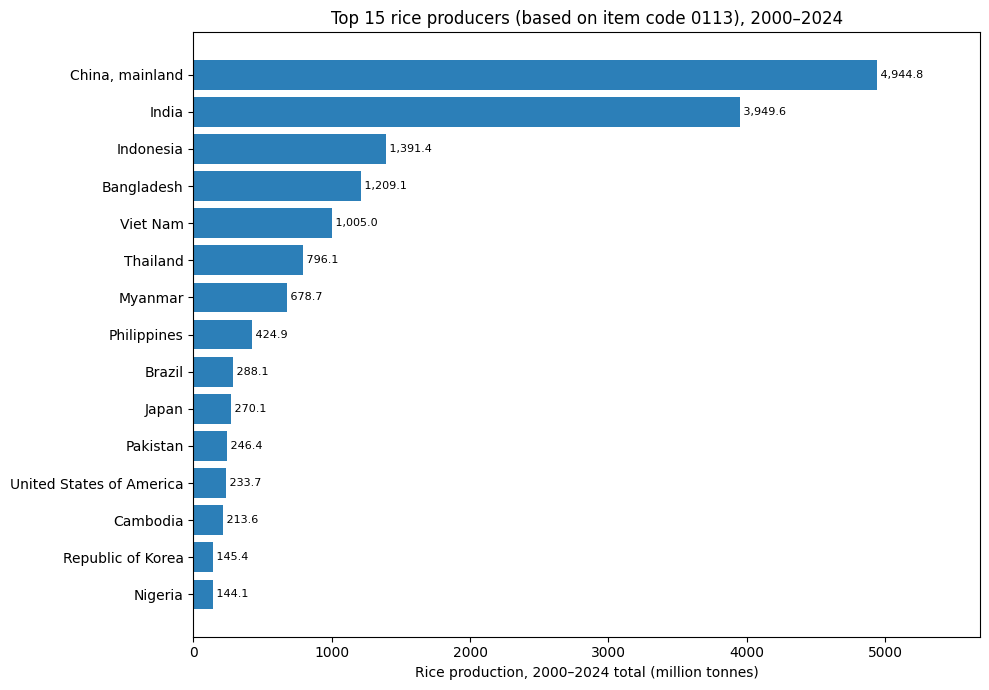

In [61]:
#Plotting the above data in bar-chart format
top = rice_production_2000_2024.nlargest(15, 'production_t').sort_values('production_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['production_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Rice production, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice producers (based on item code 0113), 2000–2024")

for y, v in enumerate(top['production_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

### This is essential for Section 2 

In [62]:
# Add each country's share of total world cotton production, 2000-2024
rice_production_2000_2024['pct_share_production'] = (
    rice_production_2000_2024['production_t']
    / rice_production_2000_2024['production_t'].sum()
    * 100
)

# Re-sort and assign rank
rice_production_2000_2024 = (
    rice_production_2000_2024
    .sort_values('production_t', ascending=False)
    .reset_index(drop=True)
)

rice_production_2000_2024['rank'] = (
    rice_production_2000_2024.index + 1
)

print(rice_production_2000_2024)

                                 Area  production_t  pct_share_production  rank
0                     China, mainland 4944787500.00                 28.20     1
1                               India 3949568648.52                 22.52     2
2                           Indonesia 1391403356.54                  7.93     3
3                          Bangladesh 1209116494.14                  6.89     4
4                            Viet Nam 1004997339.59                  5.73     5
..                                ...           ...                   ...   ...
136                        Luxembourg          0.00                  0.00   137
137                           Germany          0.00                  0.00   138
138                           Belgium          0.00                  0.00   139
139                           Finland          0.00                  0.00   140
140  Saint Vincent and the Grenadines          0.00                  0.00   141

[141 rows x 4 columns]


In [63]:
#This is the average production 
avg_rice_production_2000_2024 = (
    rice_by_area_year[
        (rice_by_area_year['Year'] >= 2000) &
        (rice_by_area_year['Year'] <= 2024)
    ]
    .groupby('Area')['production_t']
    .mean()
    .reset_index()
    .sort_values('production_t', ascending=False)
)

print(avg_rice_production_2000_2024)

                                 Area  production_t
23                    China, mainland  197791500.00
59                              India  157982745.94
60                          Indonesia   55656134.26
7                          Bangladesh   48364659.77
138                          Viet Nam   40199893.58
..                                ...           ...
99                             Poland          0.00
30                             Cyprus          0.00
111                          Slovakia          0.00
112                          Slovenia          0.00
107  Saint Vincent and the Grenadines          0.00

[141 rows x 2 columns]


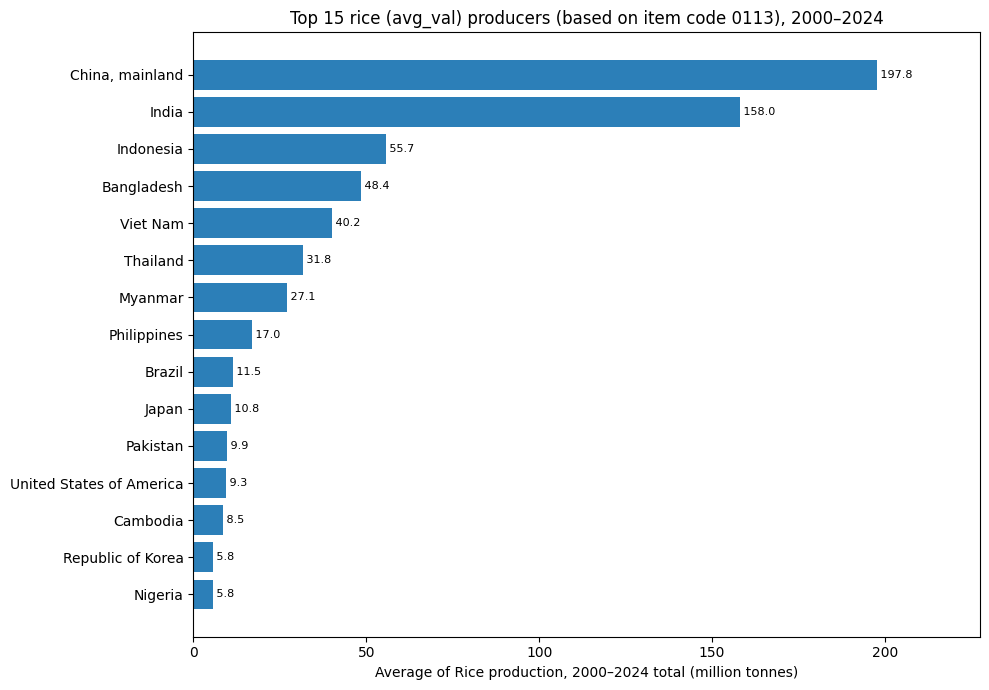

In [64]:
#Plotting the above data in bar-chart format
top = avg_rice_production_2000_2024.nlargest(15, 'production_t').sort_values('production_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['production_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Average of Rice production, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice (avg_val) producers (based on item code 0113), 2000–2024")

for y, v in enumerate(top['production_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [65]:
#Adding the world percentage values and ranks in terms of average production 
# This should almost match with teh total production above
avg_rice_production_2000_2024['pct_of_world'] = (
    avg_rice_production_2000_2024['production_t']
    / avg_rice_production_2000_2024['production_t'].sum() * 100
)

avg_rice_production_2000_2024 = avg_rice_production_2000_2024.reset_index(drop=True)
avg_rice_production_2000_2024['rank'] = avg_rice_production_2000_2024.index + 1

print(avg_rice_production_2000_2024)

                                 Area  production_t  pct_of_world  rank
0                     China, mainland  197791500.00         28.19     1
1                               India  157982745.94         22.52     2
2                           Indonesia   55656134.26          7.93     3
3                          Bangladesh   48364659.77          6.89     4
4                            Viet Nam   40199893.58          5.73     5
..                                ...           ...           ...   ...
136                            Poland          0.00          0.00   137
137                            Cyprus          0.00          0.00   138
138                          Slovakia          0.00          0.00   139
139                          Slovenia          0.00          0.00   140
140  Saint Vincent and the Grenadines          0.00          0.00   141

[141 rows x 4 columns]


If needed we can add code specific to production between 2022-2024

In [308]:
# WINDOW_SIZE = 5
# START, END = 2000, 2024

# def window_label(y):
#     lo = START + ((y - START) // WINDOW_SIZE) * WINDOW_SIZE
#     return f"{lo}-{lo + WINDOW_SIZE - 1}"

# # avg annual production (Mt) per country per 5-year window
# pc = rice_by_area_year[rice_by_area_year['Year'].between(START, END)].copy()
# pc['window'] = pc['Year'].apply(window_label)
# per_country = (pc.groupby(['Area', 'window'])['production_t'].mean()
#                  .div(1e6)                        # -> million tonnes
#                  .unstack('window'))

# # pick top 10 producers by the most recent window, keep windows in chronological order
# windows = sorted(per_country.columns, key=lambda w: int(w[:4]))
# last_win = window_label(END)
# top10 = per_country.sort_values(last_win, ascending=False).head(10)[windows]

# # grouped bars
# x = np.arange(len(top10))            # one group per country
# n = len(windows)
# bar_w = 0.8 / n
# colors = plt.cm.viridis(np.linspace(0.15, 0.9, n))

# plt.figure(figsize=(13, 6))
# for i, win in enumerate(windows):
#     plt.bar(x + i * bar_w, top10[win].values, width=bar_w, label=win, color=colors[i])

# plt.xticks(x + 0.4 - bar_w / 2, top10.index, rotation=45, ha='right')
# plt.ylabel("Avg annual production (million tonnes, rice)")
# plt.title("Top 10 rice producers — average annual production by 5-year window (2000–2024)")
# plt.legend(title="Year bin", ncol=len(windows))
# plt.tight_layout()
# plt.show()

In [309]:
# WINDOW_SIZE = 5
# START, END = 2000, 2024

# def window_label(y):
#     lo = START + ((y - START) // WINDOW_SIZE) * WINDOW_SIZE
#     return f"{lo}-{lo + WINDOW_SIZE - 1}"

# # avg annual production (Mt) per country per 5-year window
# pc = rice_by_area_year[rice_by_area_year['Year'].between(START, END)].copy()
# pc['window'] = pc['Year'].apply(window_label)
# per_country = (pc.groupby(['Area', 'window'])['production_t'].mean()
#                  .div(1e6)                        # -> million tonnes
#                  .unstack('window'))

# windows = sorted(per_country.columns, key=lambda w: int(w[:4]))

# # rank by avg annual production over the full 2000–2024 period (from yearly data)
# overall = pc.groupby('Area')['production_t'].mean().div(1e6)     # Mt
# rank_order = overall.sort_values(ascending=False).head(15).index

# top15 = per_country.loc[rank_order, windows].round(1)
# top15.insert(0, 'avg_2000_2024_Mt', overall.loc[rank_order].round(1))

# print("Top 15 rice producers — avg annual production (million tonnes, paddy):")
# print(top15.to_string())

<!-- ### How much of the rice is exported outside? And export/import analysis into one
1. Export share of production — How much of what it grows does it ship out?
Formula: export_share = export_qty ÷ production (done)

2. Net trade position - Is it a net seller or net buyer? (To do?)
Formula: net_exports = export_qty − import_qty  = 36,160.97 − 0.13 ≈ 36,160.84 t

3. apparent_supply = production − export_qty + import_qty (to-do?)

4. Self sufficieny ratio (SSR) (to-do?)
SSR = production ÷ (production − export_qty + import_qty)
SSR > 1 means the country grows more than it consumes (net exporter); SSR < 1 means it leans on imports. -->

 ### Section 1b: TCL data analysis: How much of produced rice enters international trade?

In [66]:
# TCL bulk download (Trade: Crops and livestock products)
BULK_URL = 'https://bulks-faostat.fao.org/production/Trade_CropsLivestock_E_All_Data_(Normalized).zip'
if not os.path.exists('tcl_bulk.zip'):
    print('Downloading TCL bulk file (~261 MB, a few minutes)...')
    urllib.request.urlretrieve(BULK_URL, 'tcl_bulk.zip')

with zipfile.ZipFile('tcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n
                and 'Elements' not in n][0]
    print(f'Reading {csv_name}...')
    tcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)

    item_csv = [n for n in z.namelist() if 'ItemCodes' in n][0]
    tcl_item_codes = pd.read_csv(z.open(item_csv), encoding='latin-1')

    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    tcl_area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(f'Full TCL: {len(tcl_all):,} rows')

Reading Trade_CropsLivestock_E_All_Data_(Normalized).csv...
Full TCL: 17,143,873 rows


In [67]:
print(tcl_all.head())

   Area Code Area Code (M49)         Area  Item Code Item Code (CPC)               Item  Element Code  \
0          2            '004  Afghanistan        221          '01371  Almonds, in shell          5610   
1          2            '004  Afghanistan        221          '01371  Almonds, in shell          5610   
2          3            '008      Albania        221          '01371  Almonds, in shell          5610   
3          4            '012      Algeria        221          '01371  Almonds, in shell          5610   
4          3            '008      Albania        221          '01371  Almonds, in shell          5610   

           Element  Year Code  Year Unit  Value Flag                                            Note  
0  Import quantity       2014  2014    t  34.46    X  Estimated data using trading partners database  
1  Import quantity       2015  2015    t  75.50    X  Estimated data using trading partners database  
2  Import quantity       1996  1996    t  87.00    A        

### Section 1b (1): Using code Item code 27 specifically as layer 1 for analysis: (Rice from QCL to rice in TCL)
This analysis isnt fair comparision since the code deosnt give the full picture, reference papers:
Reference PDF: https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content (page 723)
https://openknowledge.fao.org/handle/20.500.14283/at163e (page 23)

In [68]:
# Verify the Rice item code before trusting it — same discipline as the original
# Don't assume the code is 113: derive it from this file's own lookup table, the same way
rice_matches = item_codes[item_codes['Item'].str.contains('Rice', case=False, na=False)][['Item Code', 'Item']]
print(rice_matches.to_string(index=False))

exact = rice_matches[rice_matches['Item'].str.fullmatch('Rice', case=False)]
if len(exact):
    CONFIG['crop_item_code'] = int(exact.iloc[0]['Item Code'])
else:
    print("No exact 'Rice' match in the lookup — check the table above and set CONFIG['crop_item_code'] manually.")
    CONFIG['crop_item_code'] = int(rice_matches.iloc[0]['Item Code'])  # best-effort fallback

print(f"Using Item Code {CONFIG['crop_item_code']} for Rice")

Item Code Item
       27 Rice
Using Item Code 27 for Rice


In [69]:
# filter to Rice Production (tonnes), then drop regional/continental aggregates (< 5000)
# AND the China aggregates/territories (keeping mainland 41 only, per CONFIG).
tcl_rice = tcl_all[(tcl_all['Item Code'] == CONFIG['crop_item_code']) & (tcl_all['Element'] == 'Export quantity')].copy()
print(f"Rice, Export element: {len(tcl_rice):,} rows, unit(s): {tcl_rice['Unit'].unique()}")
print(tcl_rice.head())

# build the valid-country set: below the aggregate cutoff AND not an excluded China code
area_code_exclude = area_codes[
    (area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))

tcl_rice = tcl_rice[tcl_rice['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + doubly counted codes (for China): {len(tcl_rice):,} rows, {tcl_rice['Area'].nunique()} countries")
# print(tcl_rice.head())

rice_by_area_year_traded_c27 = tcl_rice.groupby(['Area', 'Area Code', 'Year'])['Value'].sum().reset_index(name='exported_t')

Rice, Export element: 9,607 rows, unit(s): ['t']
         Area Code Area Code (M49)                                         Area  Item Code Item Code (CPC)  Item  \
422206         261       '097.1203  European Union (12) (excluding intra-trade)         27           '0113  Rice   
1206606        268       '097.2503  European Union (25) (excluding intra-trade)         27           '0113  Rice   
1206888        268       '097.2503  European Union (25) (excluding intra-trade)         27           '0113  Rice   
1207162        268       '097.2503  European Union (25) (excluding intra-trade)         27           '0113  Rice   
1668863        277            '728                                  South Sudan         27           '0113  Rice   

         Element Code          Element  Year Code  Year Unit   Value Flag  \
422206           5910  Export quantity       1994  1994    t 2278.00    E   
1206606          5910  Export quantity       2004  2004    t 1774.00    E   
1206888          5910  

In [70]:
rice_by_area_year_traded_c27

,Area,Area Code,Year,exported_t
0,Afghanistan,2,2016,64.74
1,Afghanistan,2,2023,0.05
2,Afghanistan,2,2024,1.50
3,Albania,3,1999,69.00
4,Albania,3,2000,5.00
...,...,...,...,...
6199,Zimbabwe,181,2010,60.00
6200,Zimbabwe,181,2011,30.00
6201,Zimbabwe,181,2012,158.00
6202,Zimbabwe,181,2013,0.00


In [71]:
# World rice traded per year in tonnes
world_trade_over_year = rice_by_area_year_traded_c27.groupby('Year')['exported_t'].sum().reset_index()
print(world_trade_over_year)

# #Export share
# export_share = (world_trade_over_year['exported_t']/world_production_over_year['production_t']) * 100
# print(export_share)


    Year  exported_t
0   1961   474204.00
1   1962   459180.00
2   1963   452447.00
3   1964   534113.00
4   1965   474455.00
..   ...         ...
59  2020  3141741.69
60  2021  3033079.68
61  2022  3074840.01
62  2023  4122433.33
63  2024  8128666.09

[64 rows x 2 columns]


#### Which countries exported the most rice (code 27) over the entire 2000–2024 period? 
Note: Top exporters, shown below are based on the the FAOSTAT Rice (0113 or Item code 27) trade classification.

In [72]:
#Total exports of rice (code 27) between 2000-2024
rice_exports_2000_2024_c27 = (
    rice_by_area_year_traded_c27[
        (rice_by_area_year_traded_c27['Year'] >= 2000) &
        (rice_by_area_year_traded_c27['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .sum()
    .reset_index()
    .sort_values('exported_t', ascending=False)
)

print(rice_exports_2000_2024_c27)


                         Area  exported_t
160  United States of America 37913029.02
26                   Cambodia  6145726.02
21                     Brazil  5252875.33
69                      India  4332165.17
161                   Uruguay  1941181.21
..                        ...         ...
96           Marshall Islands        0.04
116          Papua New Guinea        0.00
88                      Libya        0.00
128     Saint Kitts and Nevis        0.00
153                   Tunisia        0.00

[168 rows x 2 columns]


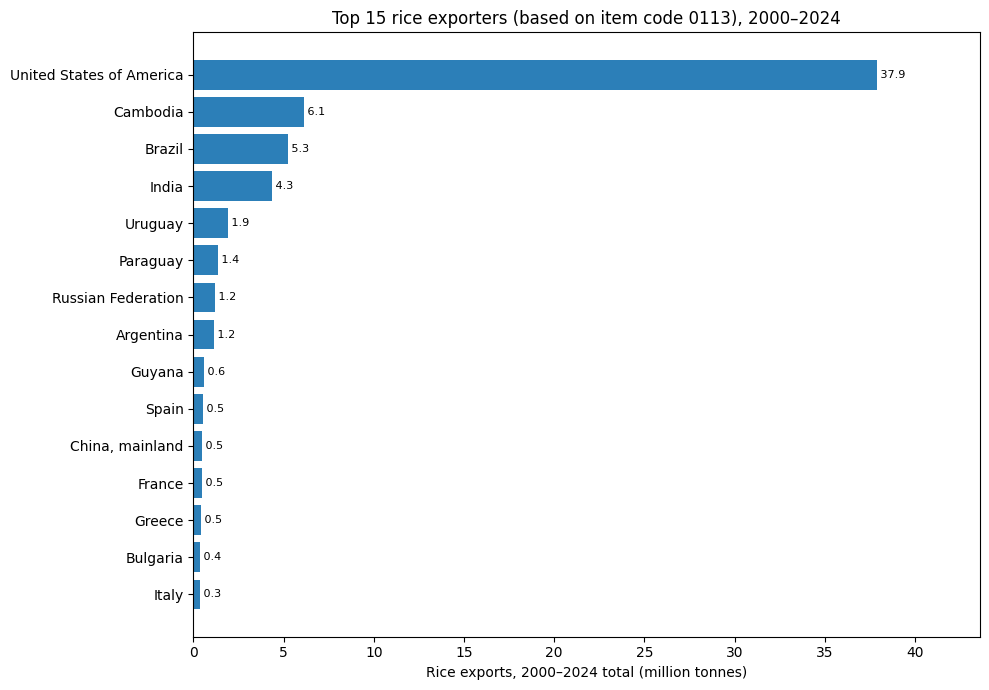

In [81]:
#Plotting the above data in bar chart
top = rice_exports_2000_2024_c27.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Rice exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice exporters (based on item code 0113), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

### Section 1b (1.2): Percentage and rank analysis for code 27 alone

In [74]:
# Add each country's share of total world cotton production, 2000-2024
rice_exports_2000_2024_c27['pct_share_export'] = (
    rice_exports_2000_2024_c27['exported_t']
    / rice_exports_2000_2024_c27['exported_t'].sum()
    * 100
)

# Re-sort and assign rank
rice_exports_2000_2024_c27 = (
    rice_exports_2000_2024_c27
    .sort_values('exported_t', ascending=False)
    .reset_index(drop=True)
)

rice_exports_2000_2024_c27['rank'] = (
    rice_exports_2000_2024_c27.index + 1
)

print(rice_exports_2000_2024_c27)

                         Area  exported_t  pct_share_export  rank
0    United States of America 37913029.02             58.71     1
1                    Cambodia  6145726.02              9.52     2
2                      Brazil  5252875.33              8.13     3
3                       India  4332165.17              6.71     4
4                     Uruguay  1941181.21              3.01     5
..                        ...         ...               ...   ...
163          Marshall Islands        0.04              0.00   164
164          Papua New Guinea        0.00              0.00   165
165                     Libya        0.00              0.00   166
166     Saint Kitts and Nevis        0.00              0.00   167
167                   Tunisia        0.00              0.00   168

[168 rows x 4 columns]


In [32]:
#Average exports of rice (code 27) between 2000-2024
average_rice_exports_2000_2024_c27 = (
    rice_by_area_year_traded_c27[
        (rice_by_area_year_traded_c27['Year'] >= 2000) &
        (rice_by_area_year_traded_c27['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .mean()
    .reset_index()
    .sort_values('exported_t', ascending=False)
)

print(average_rice_exports_2000_2024_c27)


                         Area  exported_t
160  United States of America  1516521.16
26                   Cambodia   438980.43
21                     Brazil   210115.01
69                      India   173286.61
161                   Uruguay    77647.25
..                        ...         ...
5                     Armenia        0.03
153                   Tunisia        0.00
88                      Libya        0.00
128     Saint Kitts and Nevis        0.00
116          Papua New Guinea        0.00

[168 rows x 2 columns]


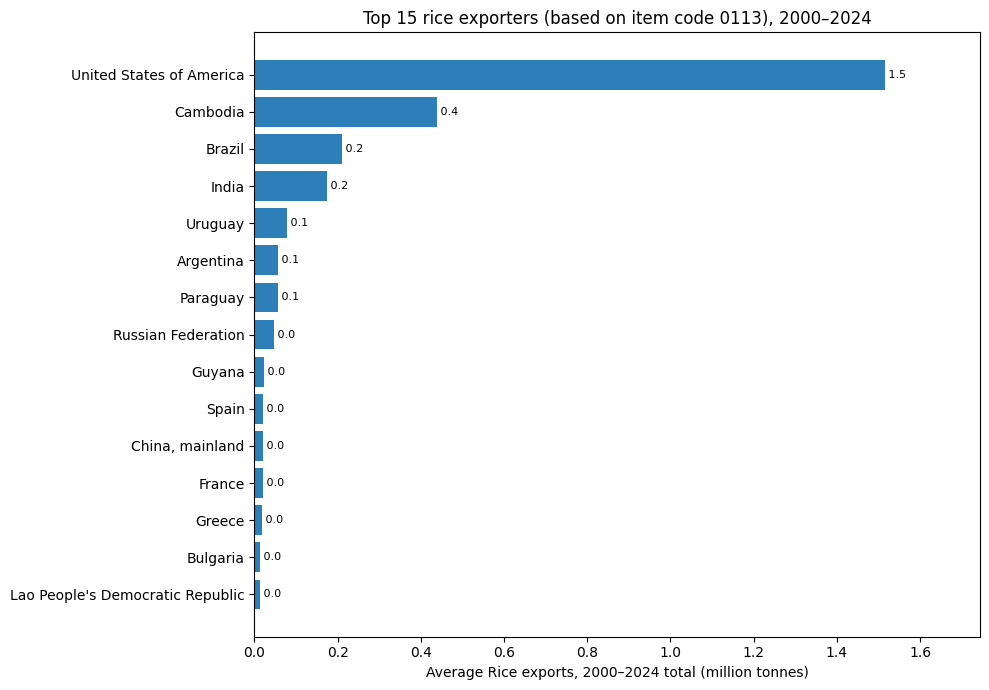

In [33]:
#Plotting the above data in bar chart
top = average_rice_exports_2000_2024_c27.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Average Rice exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice exporters (based on item code 0113), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [34]:
#Adding the world percentage values and ranks in terms of average production
#Similar to the totals above Section 1.b (1.2)
average_rice_exports_2000_2024_c27['pct_of_world'] = (
    average_rice_exports_2000_2024_c27['exported_t']
    / average_rice_exports_2000_2024_c27['exported_t'].sum() * 100
)

average_rice_exports_2000_2024_c27 = average_rice_exports_2000_2024_c27.reset_index(drop=True)
average_rice_exports_2000_2024_c27['rank'] = average_rice_exports_2000_2024_c27.index + 1

print(average_rice_exports_2000_2024_c27)

                         Area  exported_t  pct_of_world  rank
0    United States of America  1516521.16         53.85     1
1                    Cambodia   438980.43         15.59     2
2                      Brazil   210115.01          7.46     3
3                       India   173286.61          6.15     4
4                     Uruguay    77647.25          2.76     5
..                        ...         ...           ...   ...
163                   Armenia        0.03          0.00   164
164                   Tunisia        0.00          0.00   165
165                     Libya        0.00          0.00   166
166     Saint Kitts and Nevis        0.00          0.00   167
167          Papua New Guinea        0.00          0.00   168

[168 rows x 4 columns]


### Insights using original code for rice 27
USA which is the 12th largest producer for rice (0113), shows up as 1st largest exporter.
Out of (production amount code 27 for US) only 37.9 mT is being exported, that 

hence this code 0113 (Rice Item Code 27) is not a good comparision or rice production and trade, the by products of rice instead are based on the conversion factor

### Section 1b (2): Using code Item codes 31 and 28 specifically as layer 2 for analysis:
Rice from QCL to husked rice(code 28) and Milled paddy rice(code 31) in TCL
This analysis isnt fair comparision since the code doesnt give the full picture, reference papers:
Reference PDF: https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content (page 723)
https://openknowledge.fao.org/handle/20.500.14283/at163e (page 23)

Using the code quivalents and conversions based on the PDF(Page 723) (https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content)

In [249]:
# tcl_all

In [39]:
#  filter TCL to the two rice trade items, Export quantity (tonnes), drop aggregates
# (< 5000) + China aggregates/territories, and lift each milled form to paddy-equivalent with its
# own factor before summing (per the ESSB commodity tree). Reads the flat config keys directly.

rm_code,  rm_factor  = CONFIG['trade_crop_item_code_rm'],  CONFIG['rm_paddy_factor']    # 31, 0.67
rmh_code, rmh_factor = CONFIG['trade_crop_item_code_rmh'], CONFIG['rmh_paddy_factor']   # 28, 0.77

tcl_rice = tcl_all[
    (tcl_all['Item Code'].isin([rm_code, rmh_code]))
    & (tcl_all['Element'] == 'Export quantity')
].copy()
print(f"Rice trade (export): {len(tcl_rice):,} rows, unit(s): {tcl_rice['Unit'].unique()}")
print(tcl_rice['Item'].unique())

# --- lift each form to paddy-equivalent using its own factor ---
tcl_rice['paddy_factor'] = tcl_rice['Item Code'].map({rm_code: rm_factor, rmh_code: rmh_factor})
# print(tcl_rice)
tcl_rice['exported_paddy_eq_t'] = tcl_rice['Value'] * tcl_rice['paddy_factor']
# print(tcl_rice)

# build the valid-country set: below the aggregate cutoff AND not an excluded China code
area_code_exclude = tcl_area_codes[
    (tcl_area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~tcl_area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))

tcl_rice = tcl_rice[tcl_rice['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + China double-counts: {len(tcl_rice):,} rows, {tcl_rice['Area'].nunique()} countries")

# sum paddy-equivalent tonnes across BOTH forms per country-year
rice_by_area_year_traded_conversion_based = (tcl_rice
    .groupby(['Area', 'Area Code', 'Year'])['exported_paddy_eq_t']
    .sum()
    .reset_index(name='exported_t'))

Rice trade (export): 21,415 rows, unit(s): ['t']
['Husked rice' 'Rice, milled']
After dropping aggregates + China double-counts: 14,599 rows, 202 countries


In [40]:
rice_by_area_year_traded_conversion_based

,Area,Area Code,Year,exported_t
0,Afghanistan,2,2014,0.30
1,Afghanistan,2,2015,44.77
2,Afghanistan,2,2018,11.97
3,Afghanistan,2,2019,4390.56
4,Afghanistan,2,2020,3.50
...,...,...,...,...
9248,Zimbabwe,181,2013,120.60
9249,Zimbabwe,181,2015,0.07
9250,Zimbabwe,181,2016,2.68
9251,Zimbabwe,181,2017,0.35


In [41]:
# World rice traded per year in tonnes
world_trade_yearwise = rice_by_area_year_traded_conversion_based.groupby('Year')['exported_t'].sum().reset_index()
print(world_trade_yearwise)


    Year  exported_t
0   1961  3949005.49
1   1962  4213355.35
2   1963  5031932.24
3   1964  5213491.01
4   1965  5225108.40
..   ...         ...
59  2020 27321277.23
60  2021 30279243.79
61  2022 32714967.76
62  2023 31726106.97
63  2024 33554260.33

[64 rows x 2 columns]


In [75]:
#Total rice exported for rice codes (31, 28) 
#Note the reason for selecting only these codes is in PDF link (page 723) above
rice_exports_eq_2000_2024 = (
    rice_by_area_year_traded_conversion_based[
        (rice_by_area_year_traded_conversion_based['Year'] >= 2000) &
        (rice_by_area_year_traded_conversion_based['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .sum()
    .reset_index()
    .sort_values('exported_t', ascending=False)
)

print(rice_exports_eq_2000_2024)

                         Area   exported_t
83                      India 135679245.82
176                  Thailand 126175157.19
193                  Viet Nam  87087841.00
134                  Pakistan  52830405.85
188  United States of America  34757604.57
..                        ...          ...
109                  Maldives         0.05
39               Cook Islands         0.05
4         Antigua and Barbuda         0.01
164                   Somalia         0.00
56                    Eritrea         0.00

[197 rows x 2 columns]


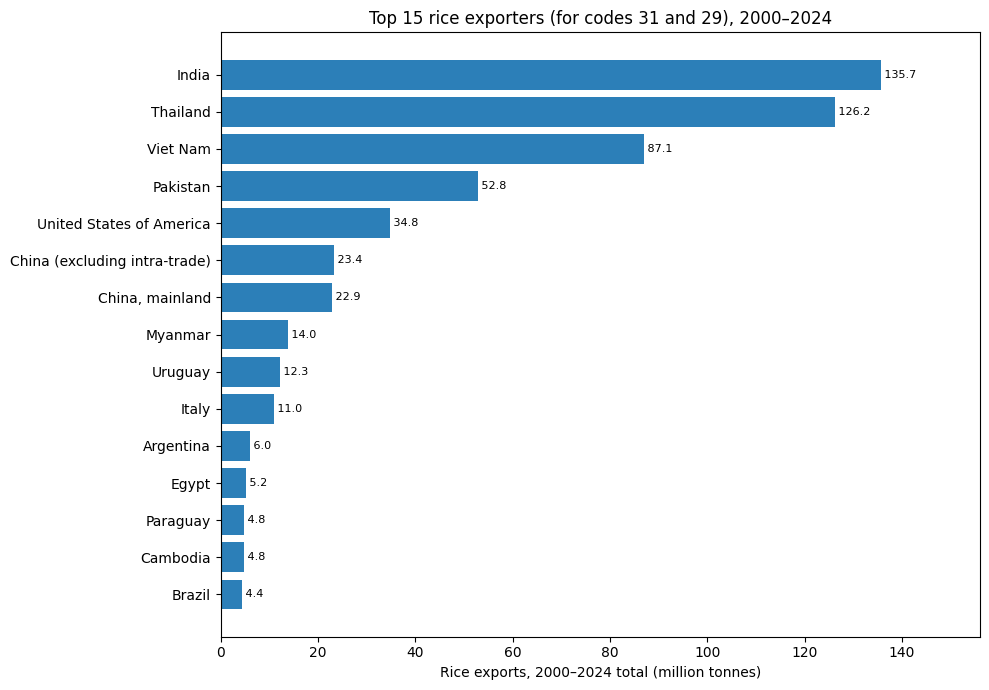

In [76]:
#Plotting the above in bar chart
top = rice_exports_eq_2000_2024.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Rice exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice exporters (for codes 31 and 29), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [77]:
# Add each country's share of total world cotton production, 2000-2024
rice_exports_eq_2000_2024['pct_share_export'] = (
    rice_exports_eq_2000_2024['exported_t']
    / rice_exports_eq_2000_2024['exported_t'].sum()
    * 100
)

# Re-sort and assign rank
rice_exports_eq_2000_2024 = (
    rice_exports_eq_2000_2024
    .sort_values('exported_t', ascending=False)
    .reset_index(drop=True)
)

rice_exports_eq_2000_2024['rank'] = (
    rice_exports_eq_2000_2024.index + 1
)

print(rice_exports_eq_2000_2024)

                         Area   exported_t  pct_share_export  rank
0                       India 135679245.82             23.10     1
1                    Thailand 126175157.19             21.48     2
2                    Viet Nam  87087841.00             14.83     3
3                    Pakistan  52830405.85              8.99     4
4    United States of America  34757604.57              5.92     5
..                        ...          ...               ...   ...
192                  Maldives         0.05              0.00   193
193              Cook Islands         0.05              0.00   194
194       Antigua and Barbuda         0.01              0.00   195
195                   Somalia         0.00              0.00   196
196                   Eritrea         0.00              0.00   197

[197 rows x 4 columns]


In [78]:
#Average rice exported for rice codes (31, 29) 
#Note the reason for selecting only these codes is in PDF link (page 723) above
avg_rice_exports_eq_2000_2024 = (
    rice_by_area_year_traded_conversion_based[
        (rice_by_area_year_traded_conversion_based['Year'] >= 2000) &
        (rice_by_area_year_traded_conversion_based['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .mean()
    .reset_index()
    .sort_values('exported_t', ascending=False)
)

print(avg_rice_exports_eq_2000_2024)

                         Area  exported_t
83                      India  5427169.83
176                  Thailand  5047006.29
193                  Viet Nam  3483513.64
134                  Pakistan  2113216.23
188  United States of America  1390304.18
..                        ...         ...
109                  Maldives        0.02
39               Cook Islands        0.02
4         Antigua and Barbuda        0.00
164                   Somalia        0.00
56                    Eritrea        0.00

[197 rows x 2 columns]


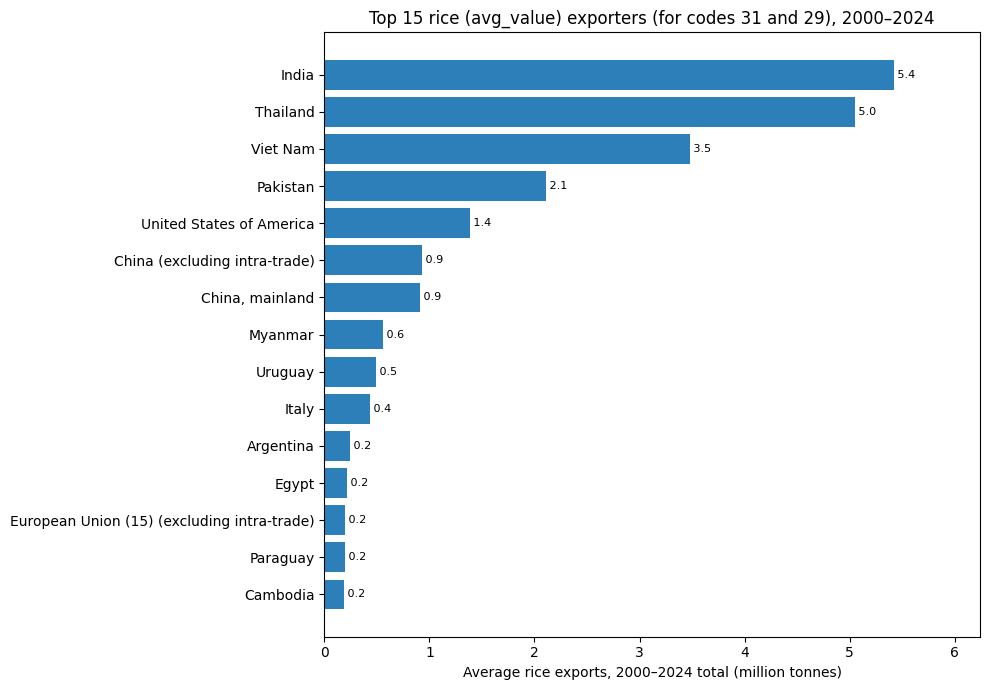

In [79]:
#Plotting the above in bar chart
top = avg_rice_exports_eq_2000_2024.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Average rice exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice (avg_value) exporters (for codes 31 and 29), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [80]:
#Adding the world percentage values and ranks in terms of average production
avg_rice_exports_eq_2000_2024['pct_share_export'] = (
    avg_rice_exports_eq_2000_2024['exported_t']
    / avg_rice_exports_eq_2000_2024['exported_t'].sum() * 100
)

avg_rice_exports_eq_2000_2024 = avg_rice_exports_eq_2000_2024.reset_index(drop=True)
avg_rice_exports_eq_2000_2024['rank'] = avg_rice_exports_eq_2000_2024.index + 1

print(avg_rice_exports_eq_2000_2024)

                         Area  exported_t  pct_share_export  rank
0                       India  5427169.83             22.67     1
1                    Thailand  5047006.29             21.08     2
2                    Viet Nam  3483513.64             14.55     3
3                    Pakistan  2113216.23              8.83     4
4    United States of America  1390304.18              5.81     5
..                        ...         ...               ...   ...
192                  Maldives        0.02              0.00   193
193              Cook Islands        0.02              0.00   194
194       Antigua and Barbuda        0.00              0.00   195
195                   Somalia        0.00              0.00   196
196                   Eritrea        0.00              0.00   197

[197 rows x 4 columns]


### Insights 
Based on codes 29 and 31 the rice exports now shows the major producers as exporters and this makes sense for analysis since the original code 27 is not traded as is 

### Section 2: Production and Trade analysis countrywise to understand who are producing and who are exporting in one table

In [83]:
print(rice_production_2000_2024.head())
print(rice_exports_eq_2000_2024.head())

              Area  production_t  pct_share_production  rank
0  China, mainland 4944787500.00                 28.20     1
1            India 3949568648.52                 22.52     2
2        Indonesia 1391403356.54                  7.93     3
3       Bangladesh 1209116494.14                  6.89     4
4         Viet Nam 1004997339.59                  5.73     5
                       Area   exported_t  pct_share_export  rank
0                     India 135679245.82             23.10     1
1                  Thailand 126175157.19             21.48     2
2                  Viet Nam  87087841.00             14.83     3
3                  Pakistan  52830405.85              8.99     4
4  United States of America  34757604.57              5.92     5


In [85]:
rice_production_export = rice_production_2000_2024[
    ['Area', 'production_t', 'pct_share_production', 'rank']
].merge(
    rice_exports_eq_2000_2024[
        ['Area', 'exported_t', 'pct_share_export', 'rank']
    ],
    on='Area',
    how='outer',
    suffixes=('_production', '_export')
)
rice_production_export = rice_production_export.rename(columns={
    'rank_production': 'production_rank',
    'rank_export': 'export_rank'
}).sort_values('production_t', ascending=False)

print(rice_production_export.head(20))

                                 Area  production_t  pct_share_production  production_rank   exported_t  \
35                    China, mainland 4944787500.00                 28.20             1.00  22881099.95   
84                              India 3949568648.52                 22.52             2.00 135679245.82   
85                          Indonesia 1391403356.54                  7.93             3.00     50813.25   
12                         Bangladesh 1209116494.14                  6.89             4.00    105926.29   
196                          Viet Nam 1004997339.59                  5.73             5.00  87087841.00   
179                          Thailand  796109925.61                  4.54             6.00 126175157.19   
122                           Myanmar  678686540.00                  3.87             7.00  13950314.51   
141                       Philippines  424852212.51                  2.42             8.00      4157.31   
22                             Brazil

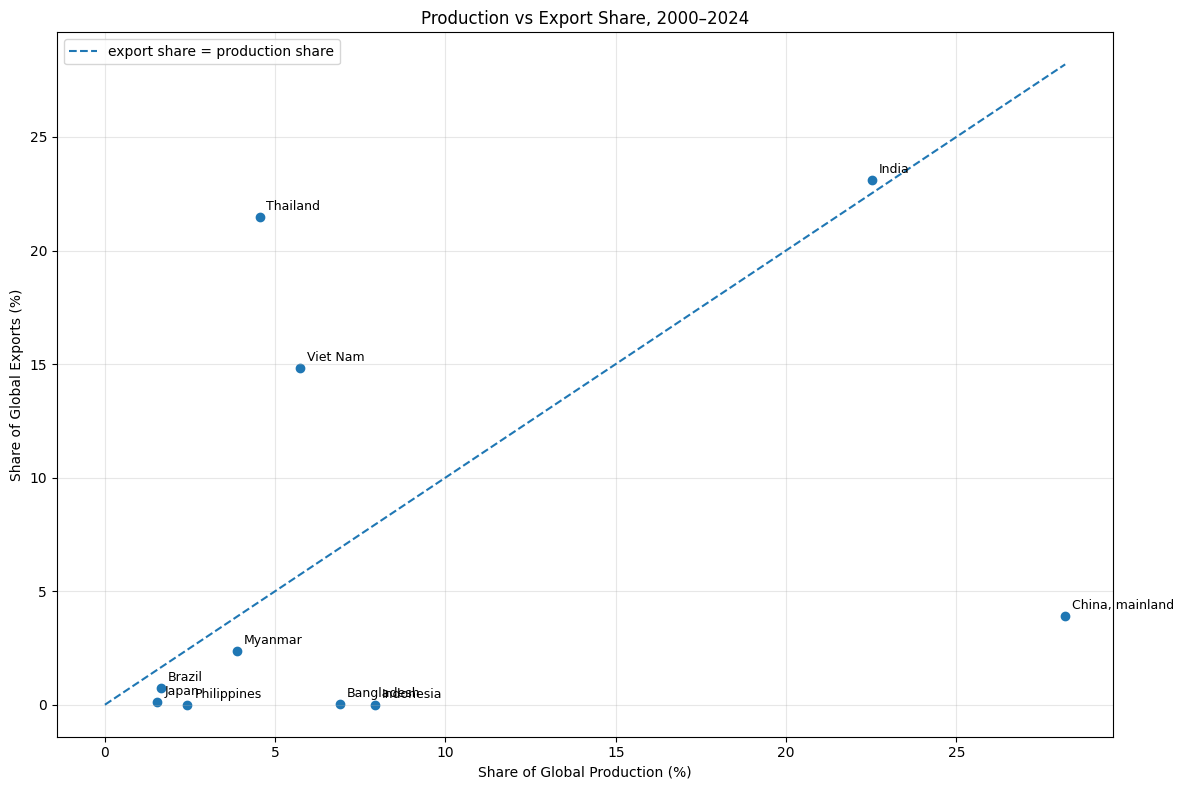

In [86]:
# Your merged production/export dataframe
plot_data = rice_production_export.copy()

# Keep top 10 producers
plot_data = (
    plot_data
    .sort_values('production_t', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 8))

plt.scatter(
    plot_data['pct_share_production'],
    plot_data['pct_share_export']
)

# Add country labels
for _, row in plot_data.iterrows():
    plt.annotate(
        row['Area'],
        (row['pct_share_production'], row['pct_share_export']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

# Add diagonal line: export share = production share
max_value = max(
    plot_data['pct_share_production'].max(),
    plot_data['pct_share_export'].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--',
    label='export share = production share'
)

plt.xlabel('Share of Global Production (%)')
plt.ylabel('Share of Global Exports (%)')
plt.title('Production vs Export Share, 2000–2024')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Insights here:

**Dual player — grows a lot AND exports a lot (on the diagonal):**

India:
1. Production share = 22.52%
2. Export share     = 23.10%
→ Only country strong on both. Top exporter, 2nd-largest producer. Exports roughly in proportion to its size.

**Export specialists — export far more than their production share (above the diagonal):**

Thailand:
1. Production share = 4.54%
2. Export share     = 21.48%
→ Grows little but ships most of it. ~5x more export share than production share.

Viet Nam:
1. Production share = 5.73%
2. Export share     = 14.83%
→ Built around rice for export. Punches ~2.5x above its production weight.

Pakistan:
1. Production share = 1.41%
2. Export share     = 8.99%
→ Small grower, major supplier. ~6x more export share than production share.

United States of America:
1. Production share = 1.33%
2. Export share     = 5.92%
→ Minor producer, meaningful exporter. Export-oriented rice sector.

**Self-consumers — grow enormous volumes, export almost nothing (far below the diagonal):**

China, mainland:
1. Production share = 28.20%
2. Export share     = 3.90%
→ World's largest producer, but keeps nearly all of it. Feeds its own population.

Indonesia:
1. Production share = 7.93%
2. Export share     = 0.01%
→ 3rd-largest producer, essentially zero exports.

Bangladesh:
1. Production share = 6.89%
2. Export share     = 0.02%
→ 4th-largest producer, negligible trade — entirely domestic.

### Takeaway
Many countries grow rice, but only a few export it. Production is spread across Asia
(China, India, Indonesia, Bangladesh, Vietnam, Thailand), while exports concentrate in
~4 countries (India, Thailand, Vietnam, Pakistan). The biggest producers (China,
Indonesia) barely trade — so if a top exporter like India restricts exports, the large
producers can't fill the gap, and global supply tightens fast.

### To be discussed:

Rather than focusing on Trade Matrix to udnerstand who buys from these countries, should we go ahead and udensratdn the water stress?
Region wise water stress (Asia, south-asia, americas)
and move ahead with next steps as Daniela mentioned in initial document (predicting 10% , 20% etc)

In [87]:
# # --- join production and paddy-equivalent exports on country, 2000–2024 averages ---
# prod = avg_rice_production_2000_2024[['Area', 'production_t']]
# exp  = avg_rice_exports_eq_2000_2024[['Area', 'exported_paddy_eq_t']]   # adjust name if different

# share = prod.merge(exp, on='Area', how='left')          # left join: keep all producers
# share['exported_paddy_eq_t'] = share['exported_paddy_eq_t'].fillna(0)   # no export row => 0



# # # --- export share of production (%) ---
# share['export_share_pct'] = (share['exported_paddy_eq_t'] / share['production_t']) * 100


# # # --- global contribution: each country's % of world production and world exports ---
# share['pct_world_prod'] = (share['production_t']        / share['production_t'].sum())       * 100
# share['pct_world_exp']  = share['exported_paddy_eq_t'] / share['exported_paddy_eq_t'].sum() * 100
# print(share.head(10))

# # # # --- classify into the three types ---
# # def classify(r):
# #     big_prod = r['pct_world_prod'] >= 3      # a major producer (~top 10-12)
# #     big_exp  = r['export_share_pct'] >= 25   # exports a substantial share of what it grows
# #     if big_prod and big_exp:  return 'Major dual'
# #     if big_prod:              return 'Giant but domestic'
# #     if big_exp:               return 'Export-oriented'
# #     return 'Minor'

# # # share['type'] = share.apply(classify, axis=1)

# # # share = share.sort_values('production_t', ascending=False).reset_index(drop=True)
# # # print(share[['Area', 'production_t', 'exported_paddy_eq_t',
# # #              'export_share_pct', 'pct_world_prod', 'pct_world_exp', 'type']]
# # #       .head(20).to_string(index=False))

In [88]:
# #Plotting the export and production value to understand the leads
# fig, ax = plt.subplots(figsize=(9, 7))
# ax.scatter(share['pct_world_prod'], share['pct_world_exp'],
#            s=40, alpha=0.6, edgecolor='white', linewidth=0.5)

# # diagonal reference: exports share == production share
# lim = max(share['pct_world_prod'].max(), share['pct_world_exp'].max()) * 1.05
# ax.plot([0, lim], [0, lim], ls='--', color='grey', lw=1, label='export share = production share')

# # label only the extreme points (big in production OR big in exports)
# prod_thr = share['pct_world_prod'].quantile(0.90)
# exp_thr  = share['pct_world_exp'].quantile(0.90)
# extremes = share[(share['pct_world_prod'] >= prod_thr) | (share['pct_world_exp'] >= exp_thr)]

# for _, r in extremes.iterrows():
#     ax.annotate(r['Area'],
#                 (r['pct_world_prod'], r['pct_world_exp']),
#                 xytext=(5, 4), textcoords='offset points', fontsize=8)

# ax.set_xlabel("Share of world rice production (%)")
# ax.set_ylabel("Share of world rice exports (%)")
# ax.set_title("Rice: production share vs export share by country (2000–2024)")
# ax.legend(fontsize=8)
# plt.tight_layout()
# plt.show()

This showcases that China although a leader in production, still is not teh major exporter of rice and would not be a good candidate for water stress indicator test